
Processing results...


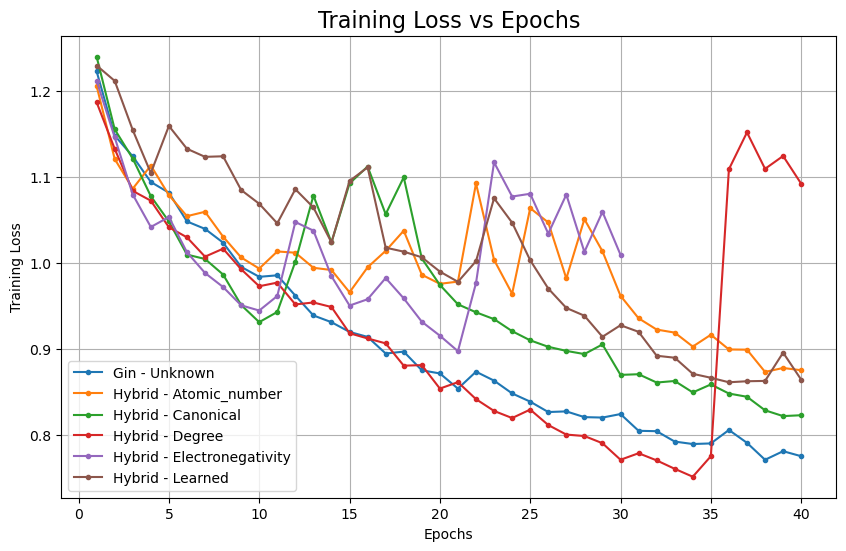

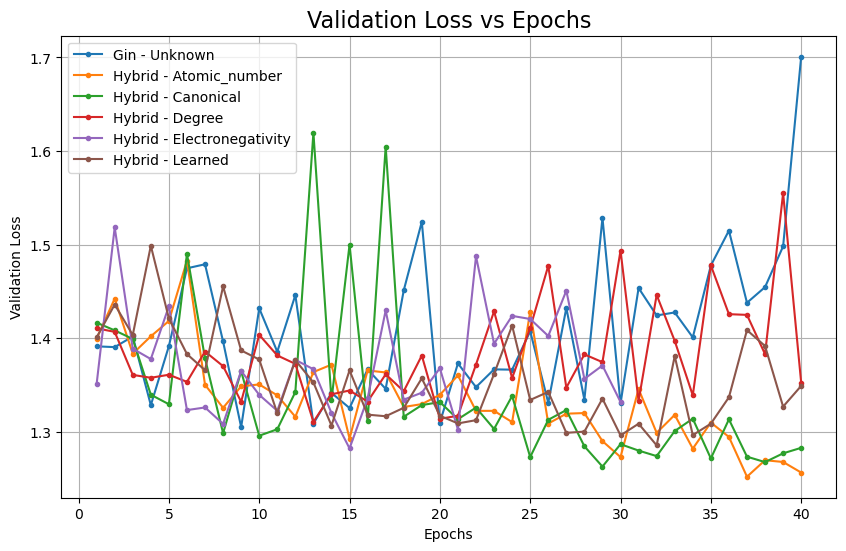

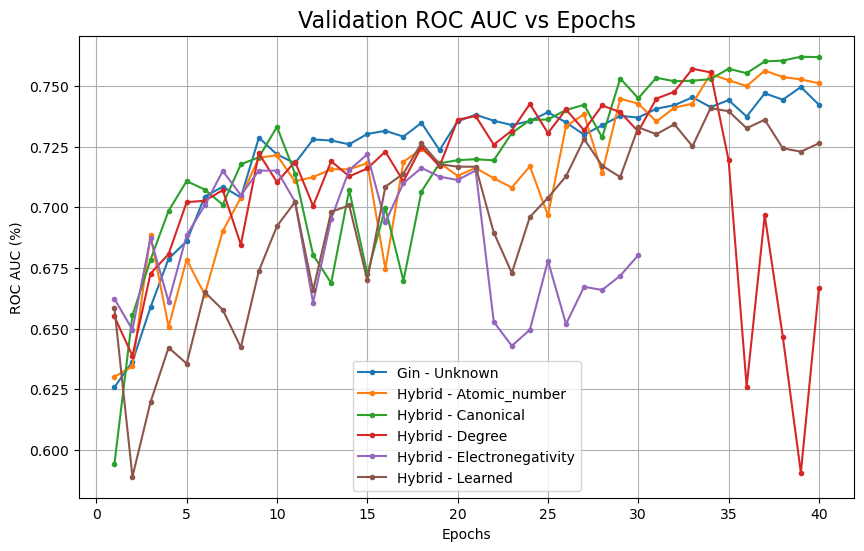

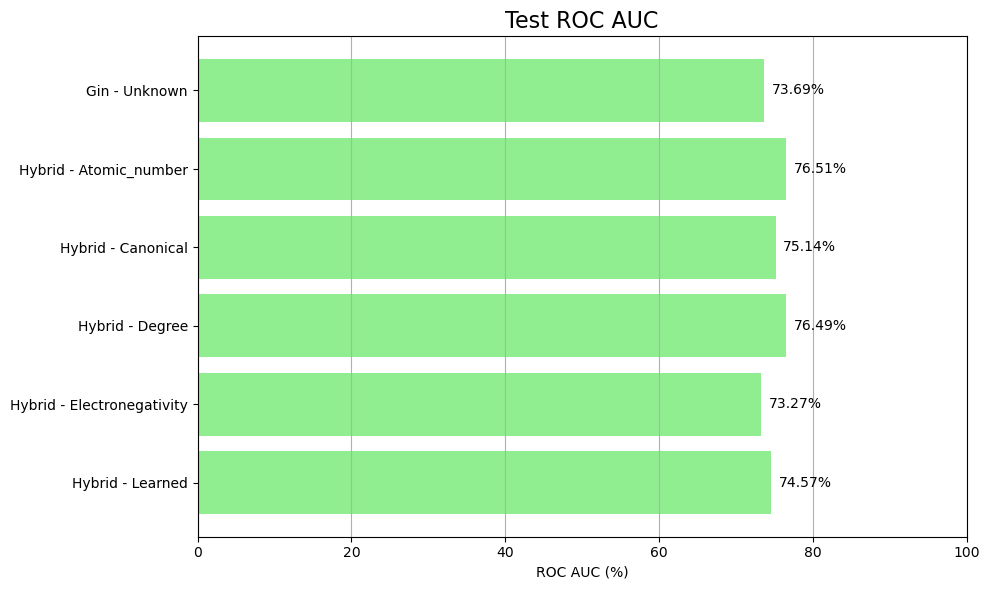

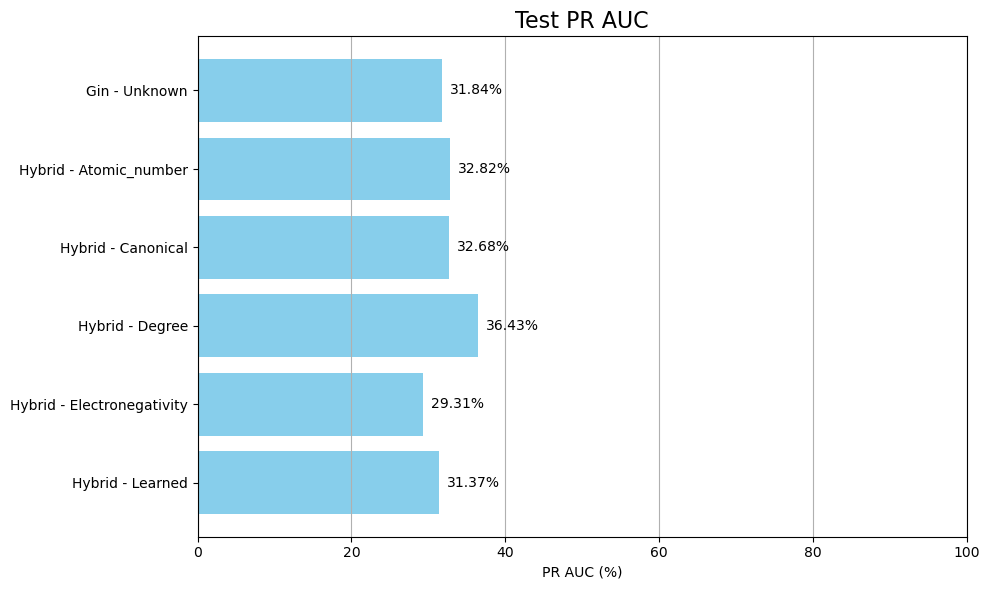

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob

def get_model_label(data):
    model_type = data.get('model_type', 'unknown')
    ordering = data.get('ordering', 'unknown')
    return f"{model_type.capitalize()} - {ordering.capitalize()}"

def process_folder(folder_path):
    folder_name = os.path.basename(folder_path.rstrip('/'))
    json_files = glob.glob(os.path.join(folder_path, '*.json'))
    
    if not json_files:
        return
        
    print(f"\nProcessing {folder_name}...")
    
    data_dict = {}
    for file in json_files:
        with open(file, 'r') as f:
            data = json.load(f)
            label = get_model_label(data)
            data_dict[label] = data
            
    labels = sorted(data_dict.keys())
        
    os.makedirs('results_images', exist_ok=True)
    
    # Plot 1: Training Loss
    plt.figure(figsize=(10, 6))
    plt.title(f"Training Loss vs Epochs", fontsize=16)
    for label in labels:
        history = data_dict[label].get('training_history', {})
        epochs = history.get('epochs', [])
        train_loss = history.get('train_loss', [])
        if epochs and train_loss:
            filtered_epochs = [e for e in epochs if e <= 40]
            filtered_train_loss = [t for e, t in zip(epochs, train_loss) if e <= 40]
            plt.plot(filtered_epochs, filtered_train_loss, label=label, marker='o', markersize=3)
    plt.xlabel('Epochs')
    plt.ylabel('Training Loss')
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.savefig(f'results_images/{folder_name}_training_loss.png', bbox_inches='tight')
    plt.show()

    # Plot 2: Validation Loss
    plt.figure(figsize=(10, 6))
    plt.title(f"Validation Loss vs Epochs", fontsize=16)
    for label in labels:
        history = data_dict[label].get('training_history', {})
        epochs = history.get('epochs', [])
        val_loss = history.get('val_loss', [])
        if epochs and val_loss:
            filtered_epochs = [e for e in epochs if e <= 40]
            filtered_val_loss = [v for e, v in zip(epochs, val_loss) if e <= 40]
            plt.plot(filtered_epochs, filtered_val_loss, label=label, marker='o', markersize=3)
    plt.xlabel('Epochs')
    plt.ylabel('Validation Loss')
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.savefig(f'results_images/{folder_name}_validation_loss.png', bbox_inches='tight')
    plt.show()

    # Plot 3: Validation ROC AUC
    plt.figure(figsize=(10, 6))
    plt.title(f"Validation ROC AUC vs Epochs", fontsize=16)
    for label in labels:
        history = data_dict[label].get('training_history', {})
        epochs = history.get('epochs', [])
        val_roc_auc = history.get('val_roc_auc', [])
        if epochs and val_roc_auc:
            filtered_epochs = [e for e in epochs if e <= 40]
            filtered_val_roc_auc_scaled = [val for e, val in zip(epochs, val_roc_auc) if e <= 40]
            plt.plot(filtered_epochs, filtered_val_roc_auc_scaled, label=label, marker='o', markersize=3)
    plt.xlabel('Epochs')
    plt.ylabel('ROC AUC (%)')
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.savefig(f'results_images/{folder_name}_validation_roc_auc.png', bbox_inches='tight')
    plt.show()

    # Plot 4: Test ROC AUC Bar Chart
    plt.figure(figsize=(10, 6))
    plt.title(f"Test ROC AUC", fontsize=16)
    roc_aucs = [data_dict[label].get('test_roc_auc', 0) * 100 for label in labels]
    y_pos = np.arange(len(labels))
    bars = plt.barh(y_pos, roc_aucs, align='center', color='lightgreen')
    plt.yticks(y_pos, labels, fontsize=10)
    plt.gca().invert_yaxis()  # labels read top-to-bottom
    plt.xlabel('ROC AUC (%)')
    plt.xlim(0, 100)
    plt.grid(True, axis='x')
    # Add exact labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
                 ha='left', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'results_images/{folder_name}_test_roc_auc.png', bbox_inches='tight')
    plt.show()

    # Plot 5: Test PR AUC Bar Chart
    plt.figure(figsize=(10, 6))
    plt.title(f"Test PR AUC", fontsize=16)
    prc_aucs = [data_dict[label].get('test_prc_auc', 0) * 100 for label in labels]
    bars = plt.barh(y_pos, prc_aucs, align='center', color='skyblue')
    plt.yticks(y_pos, labels, fontsize=10)
    plt.gca().invert_yaxis()  # labels read top-to-bottom
    plt.xlabel('PR AUC (%)')
    plt.xlim(0, 100)
    plt.grid(True, axis='x')
    # Add exact labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
                 ha='left', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'results_images/{folder_name}_test_pr_auc.png', bbox_inches='tight')
    plt.show()

# Find all results folders
results_base_dir = 'final_results'
if os.path.exists(results_base_dir):
    folders = [
        #"final_results/results_fine_tuned_random", 
        #"final_results/results_fine_tuned_scaffold", 
        #"final_results/results_not_pretrained_random", 
       # "final_results/results_not_pretrained_scaffold",
        "final_results/results"
        ]
    for folder in sorted(folders):
        process_folder(folder)
else:
    print(f"Directory {results_base_dir} not found.")
